In [ ]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [8]:
x,y  = make_circles(n_samples=100, noise=0.1, random_state=42)

Text(0.5, 1.0, 'Synthetic Dataset')

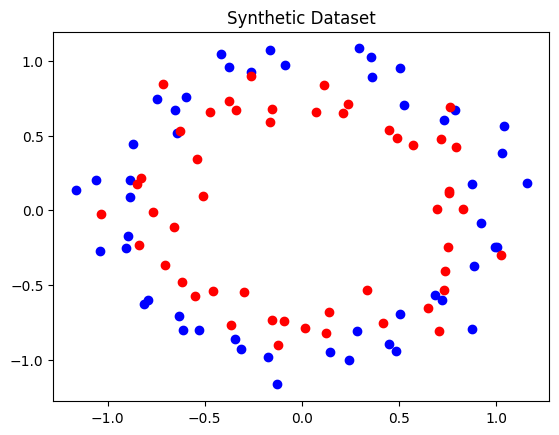

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x[y==0][:,0], x[y==0][:,1], color='blue', label='Class 0')
plt.scatter(x[y==1][:,0], x[y==1][:,1], color='red', label='Class 1')
plt.title('Synthetic Dataset')

In [10]:
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization


In [11]:
model = Sequential([
    Dense(10, activation='relu', input_shape=(2,)),
    BatchNormalization(),
    Dense(10, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

f:\Python\Deep-Learning-and-Computer-vision\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231 (924.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 40 (160.00 B)

In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x, y, epochs=100, batch_size=10, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5000 - loss: 0.7437 - val_accuracy: 0.6500 - val_loss: 0.6848
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6000 - loss: 0.6885 - val_accuracy: 0.6000 - val_loss: 0.6884
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5250 - loss: 0.6906 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5500 - loss: 0.6389 - val_accuracy: 0.4500 - val_loss: 0.6983
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.6589 - val_accuracy: 0.3000 - val_loss: 0.7029
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5750 - loss: 0.6523 - val_accuracy: 0.3500 - val_loss: 0.7063
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6375 - loss: 0.6377 - val_accuracy: 0.3500 - val_loss: 0.7117
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6375 - loss: 0.6281 - val_accuracy: 0.4000 - val_loss:

<Axes: >

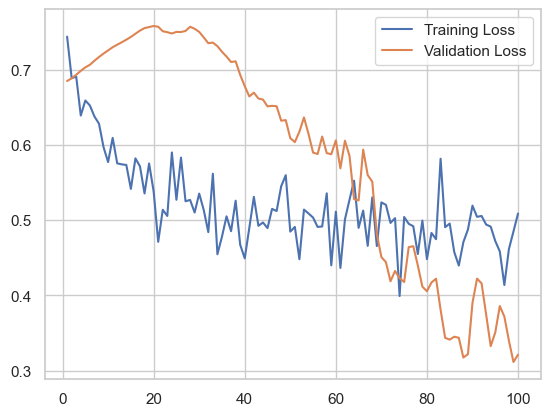

In [15]:
import seaborn as sns
sns.set(style='whitegrid')
sns.lineplot(x=range(1, 101), y=history.history['loss'], label='Training Loss')
sns.lineplot(x=range(1, 101), y=history.history['val_loss'], label='Validation Loss')

15000/15000 ━━━━━━━━━━━━━━━━━━━━ 11s 747us/step


<Axes: >

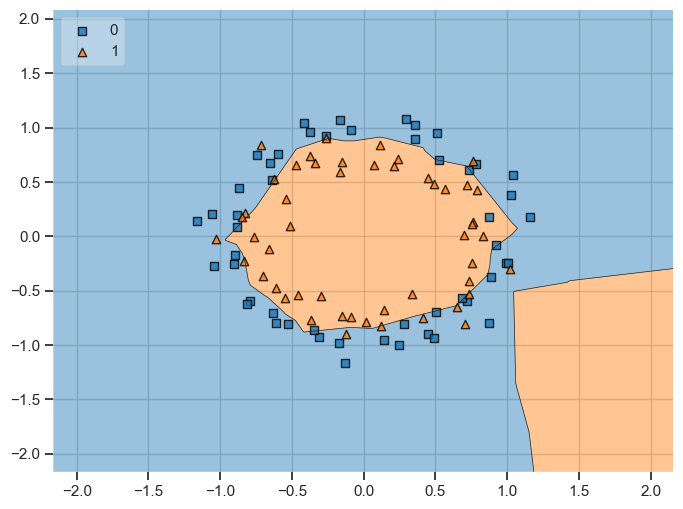

In [16]:
from mlxtend.plotting import plot_decision_regions
plt.figure(figsize=(8,6))
plot_decision_regions(x, y, clf=model, legend=2)